In [1]:
%matplotlib widget

import logging

import matplotlib.pyplot as plt
import numpy as np

import rydstate

logging.getLogger("rydstate").setLevel(logging.ERROR)

In [2]:
nu = 0, 130
l_r = 0
f_tot = 1 / 2

basis = rydstate.BasisMQDT("Yb171", nu, f_tot=(f_tot, f_tot), include_sqdt_fallback_models=False)
basis.filter_states("j_tot", (0, float("inf")), keep_unknown=False)
basis.filter_states("f_c", (0, float("inf")), keep_unknown=False)
basis.filter_states("f_tot", f_tot)
basis.filter_states("l_r", l_r, delta=0.5)
basis.filter_states("l_c", 0, delta=0.3)

basis.sort_states("nu")

print(f"{basis.species} basis states: {len(basis)}")
print(f"  nu_min = {basis.states[0].nu}, nu_max = {basis.states[-1].nu}")

Yb171 basis states: 262
  nu_min = 2.501251480224451, nu_max = 129.6095215547683


# first we look at a mainly FJ coupled state near nu=60

In [3]:
state1 = next(s for s in basis.states if abs(s.nu - 60) < 1 and s.calc_exp_qn("f_c") > 0.5)
state2 = next(s for s in basis.states if abs(s.nu - 60) < 1 and s.calc_exp_qn("f_c") < 0.5)

print(f"nu={state1.nu}: {state1}")
print(f"nu={state2.nu}: {state2}")

nu=59.61208651908746: -0.09332275293102571*(Yb171, RadialKet(nu=60.023349378742736, potential=PotentialFei2009Ytterbium171(l_r=0)), FJ(i_c=0.5, s_c=0.5, l_c=0, s_r=0.5, l_r=0, j_c=0.5, f_c=0.0, j_r=0.5, f_tot=0.5)), -0.007975681181320497*(Yb171, RadialDummy(1.0, nu=1.808404164601578), FJ(i_c=0.5, s_c=0.5, l_c=Unknown, s_r=0.5, l_r=Unknown, j_c=Unknown, f_c=Unknown, j_r=Unknown, f_tot=0.5, label=4f13 5d 6snl a)), -0.006622034835858097*(Yb171, RadialKet(nu=1.8992191127630804, potential=PotentialFei2009Ytterbium171(l_r=1)), FJ(i_c=0.5, s_c=0.5, l_c=1, s_r=0.5, l_r=1, j_c=1.5, f_c=1.0, j_r=1.5, f_tot=0.5)), 0.000215379570816273*(Yb171, RadialDummy(1.0, nu=1.808404164601578), FJ(i_c=0.5, s_c=0.5, l_c=Unknown, s_r=0.5, l_r=Unknown, j_c=Unknown, f_c=Unknown, j_r=Unknown, f_tot=0.5, label=4f13 5d 6snl b)), -2.434350412531866e-18*(Yb171, RadialKet(nu=2.0125690142769987, potential=PotentialFei2009Ytterbium171(l_r=1)), FJ(i_c=0.5, s_c=0.5, l_c=1, s_r=0.5, l_r=1, j_c=0.5, f_c=Unknown, j_r=0.5, f_t

so the states already have main contribution from just a single channel (first/last)

# now lets look at the crossovers, where FJ is not a good quantum number anymore, e.g. close to 78

In [4]:
state = next(s for s in basis.states if abs(s.nu - 78) < 1)

print(f"nu={state.nu}: {state}")
print(f"  f_c = {state.calc_exp_qn('f_c')}")

nu=77.59816362601319: -0.405385591892036*(Yb171, RadialKet(nu=78.51188346370178, potential=PotentialFei2009Ytterbium171(l_r=0)), FJ(i_c=0.5, s_c=0.5, l_c=0, s_r=0.5, l_r=0, j_c=0.5, f_c=0.0, j_r=0.5, f_tot=0.5)), -0.0036283446759909186*(Yb171, RadialDummy(1.0, nu=1.8087453031900087), FJ(i_c=0.5, s_c=0.5, l_c=Unknown, s_r=0.5, l_r=Unknown, j_c=Unknown, f_c=Unknown, j_r=Unknown, f_tot=0.5, label=4f13 5d 6snl a)), -0.0031387822833309357*(Yb171, RadialKet(nu=1.8996142811757155, potential=PotentialFei2009Ytterbium171(l_r=1)), FJ(i_c=0.5, s_c=0.5, l_c=1, s_r=0.5, l_r=1, j_c=1.5, f_c=1.0, j_r=1.5, f_tot=0.5)), 0.00010418323400793953*(Yb171, RadialDummy(1.0, nu=1.8087453031900087), FJ(i_c=0.5, s_c=0.5, l_c=Unknown, s_r=0.5, l_r=Unknown, j_c=Unknown, f_c=Unknown, j_r=Unknown, f_tot=0.5, label=4f13 5d 6snl b)), -5.683863530383736e-19*(Yb171, RadialKet(nu=2.0130392612574037, potential=PotentialFei2009Ytterbium171(l_r=1)), FJ(i_c=0.5, s_c=0.5, l_c=1, s_r=0.5, l_r=1, j_c=0.5, f_c=Unknown, j_r=0.5, 

In [5]:
# the interesting/important part here is how the radial wavefunctions are:
radial1 = state.rydberg_kets[0].radial
radial2 = state.rydberg_kets[-1].radial

print(f"{radial1.calc_overlap(radial2)=}")
# they are almost orthogonal to each other

radial1.calc_overlap(radial2)=0.09327449193456847


In [6]:
# we can also transform the whole rydberg state to LS coupling
state_ls = state.to_coupling_scheme("LS")

print(f"nu={state_ls.nu}: {state_ls}")
print(f"  j_tot = {state_ls.calc_exp_qn('j_tot')}")
# and see that the rydberg state is still a superposition of two LS states

nu=77.59816362601319: 0.8353124663366739*(Yb171, <rydstate.radial.radial_base.Radial object at 0x7f94323a5910>, LS(i_c=0.5, s_c=0.5, l_c=0, s_r=0.5, l_r=0, s_tot=0.0, l_tot=0, j_tot=0.0, f_tot=0.5)), -0.5497527344523268*(Yb171, <rydstate.radial.radial_base.Radial object at 0x7f942905f770>, LS(i_c=0.5, s_c=0.5, l_c=0, s_r=0.5, l_r=0, s_tot=1.0, l_tot=0, j_tot=1.0, f_tot=0.5)), -0.0036283446759909186*(Yb171, RadialDummy(1.0, nu=1.8087453031900087), LS(i_c=0.5, s_c=0.5, l_c=Unknown, s_r=0.5, l_r=Unknown, s_tot=Unknown, l_tot=Unknown, j_tot=Unknown, f_tot=0.5, label=4f13 5d 6snl a)), 0.001569391141665468*(Yb171, <rydstate.radial.radial_base.Radial object at 0x7f9429e17170>, LS(i_c=0.5, s_c=0.5, l_c=1, s_r=0.5, l_r=1, s_tot=0.0, l_tot=0, j_tot=0.0, f_tot=0.5)), -0.0018495451976762501*(Yb171, <rydstate.radial.radial_base.Radial object at 0x7f9429e16cf0>, LS(i_c=0.5, s_c=0.5, l_c=1, s_r=0.5, l_r=1, s_tot=0.0, l_tot=1, j_tot=1.0, f_tot=0.5)), -0.001510147330173953*(Yb171, <rydstate.radial.radi

In [7]:
# and the radial wavefunctions are still almost orthogonal to each other:
radial1 = state.rydberg_kets[0].radial
radial2 = state.rydberg_kets[-1].radial
print(f"{radial1.calc_overlap(radial2)=}")

radial1.calc_overlap(radial2)=0.09327449193456847


We can think of this as entanglement between the angular and radial part of the wavefunction.
Say we have a GHZ state |up, up> + |down, down>, where in analogy to the f_c quantum number, we could say the S_z quantum number is not a good quantum number anymore.
Now (correctly) transforming to the S_x basis, we get |+,+> + |-,->, which still is a superpostion, and for which the S_x quantum number is also not a good quantum number.

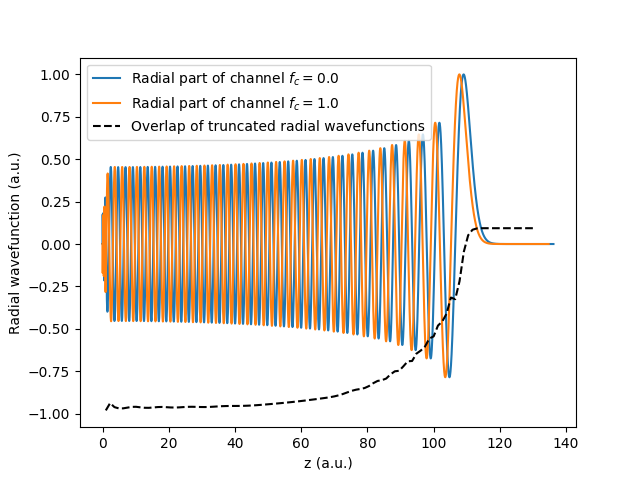

In [9]:
fig, ax = plt.subplots()
ax.plot(
    radial1.z_list,
    radial1.w_list / np.max(radial1.w_list),
    label=f"Radial part of channel $f_c={state.rydberg_kets[0].angular.f_c}$",
)
ax.plot(
    radial2.z_list,
    radial2.w_list / np.max(radial2.w_list),
    label=f"Radial part of channel $f_c={state.rydberg_kets[-1].angular.f_c}$",
)

z_list = np.linspace(1, 130, 100)
overlap_list = []
for z in z_list:
    radial1_trunc = radial1.copy().set_outside_to_zero(z**2)
    radial1_trunc /= radial1_trunc.norm
    radial2_trunc = radial2.copy().set_outside_to_zero(z**2)
    radial2_trunc /= radial2_trunc.norm
    overlap_list.append(radial1_trunc.calc_overlap(radial2_trunc))

ax.plot(z_list, overlap_list, label="Overlap of truncated radial wavefunctions", color="black", ls="--")


ax.set_xlabel("z (a.u.)")
ax.set_ylabel("Radial wavefunction (a.u.)")
ax.legend(loc="upper left")
plt.show()